## 7. `grain` dataloader

In [20]:
import grain
import matplotlib.pyplot as plt
import numpy as np
from PIL.Image import Image
import jax

import torch
import tqdm

# PyTorch imports
from torchvision import datasets
from torchvision.transforms import Lambda, ToTensor

rng = np.random.default_rng(0)

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /Users/anton/data
    Split: Train
(<PIL.Image.Image image mode=RGB size=32x32 at 0x17F51A0C0>, 6)


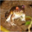

In [21]:
dataset = datasets.CIFAR10(
    root="~/data", 
    train=True, 
    download=True
)

print(dataset)
print(dataset[0])
dataset[0][0]

In [22]:
num_shards = jax.process_count()
shard_index = jax.process_index()
(num_shards, shard_index)

(1, 0)

In [ ]:
import grain.python as grain
import numpy as np
from torchvision.datasets import CIFAR10

class TorchDataSource(grain.RandomAccessDataSource):
    def __init__(self, data):
        self.data = data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img, label = self.data[idx]
        return {"image": np.array(img), "label": label}

torch_dataset = CIFAR10(root="~/data", train=True, download=True)
torch_source = TorchDataSource(torch_dataset)

loader = grain.DataLoader(
    data_source=torch_source,
    sampler=grain.IndexSampler(
        len(torch_source), 
        shuffle=True, 
        shard_options=grain.NoSharding(),
        seed=0,
    ),
    operations=[
        grain.Batch(batch_size=128)
    ],
    worker_count=4,
    worker_buffer_size=16
)

for i, batch in enumerate(loader):
    print(batch["image"].shape, batch["label"].shape)
    break

(128, 32, 32, 3) (128,)
